In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

from pathlib import Path
import cv2
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Model planning:
1. Plain CNN 1 ()
2. Deeper + Higher receptive field
3. Resnet18 encoder -> U-Net/FPN

# Loss:

In [2]:
class HeatmapCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(inplace=True)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=2, dilation=2),
            nn.ReLU(inplace=True)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=4, dilation=4),
            nn.ReLU(inplace=True)
        )
        self.conv6 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=6, dilation=6),
            nn.ReLU(inplace=True)
        )
        self.head = nn.Sequential(
            nn.Conv2d(128, 64, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.conv6(x)
        x = self.head(x)
        return x


# Instantiate model
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = HeatmapCNN().to(DEVICE)
print(f'Model on device: {DEVICE}')
print(model)

Model on device: cuda
HeatmapCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
    (1): ReLU(inplace=True)
  )
  (conv5): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(4, 4), dilation=(4, 4))
    (1): ReLU(inplace=True)
  )
  (conv6): Sequential(
    (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(6, 6), dilation=(6, 6))
    (1): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64,

In [7]:
# Training setup

# Base pixel regression loss
criterion = nn.SmoothL1Loss(reduction='none')

# Optimizer: AdamW with weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Scheduler: CosineAnnealingLR for smooth LR decay over epochs
# T_max: number of epochs for one full cosine cycle. Call scheduler.step() after each epoch.
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-6)

def total_variation_loss(x):
    """Small smoothness regularizer to reduce speckle noise in predicted heatmaps."""
    dx = torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]).mean()
    dy = torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]).mean()
    return dx + dy


def compute_composite_loss(
    pred,
    target,
    center_thr=0.3,
    edge_thr=-0.3,
    center_weight=3.0,
    edge_weight=2.0,
    bg_weight=1.0,
    edge_margin=0.1,
    lambda_reg=1.0,
    lambda_edge=0.2,
    lambda_tv=1e-5,
 ):
    """Signed heatmap loss: weighted regression + edge-sign penalty + TV regularizer."""
    # 1) Weighted SmoothL1 regression term
    pixel_loss = criterion(pred, target)  # [B, 1, H, W]
    weight = torch.full_like(target, bg_weight)
    center_mask = target > center_thr
    edge_mask = target < edge_thr
    weight[center_mask] = center_weight
    weight[edge_mask] = edge_weight
    reg_loss = (pixel_loss * weight).mean()

    # 2) Edge sign consistency term: penalize non-negative responses on edge pixels
    if edge_mask.any():
        edge_pred = pred[edge_mask]
        edge_sign_loss = torch.relu(edge_pred + edge_margin).mean()
    else:
        edge_sign_loss = pred.new_tensor(0.0)

    # 3) TV smoothness regularization
    tv_loss = total_variation_loss(pred)

    # Total
    loss = lambda_reg * reg_loss + lambda_edge * edge_sign_loss + lambda_tv * tv_loss
    return loss, reg_loss.detach(), edge_sign_loss.detach(), tv_loss.detach()


def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_reg = 0.0
    total_edge = 0.0
    total_tv = 0.0

    for batch_idx, (images, targets) in enumerate(dataloader):
        images = images.to(device)  # [B, 1, H, W]
        targets = targets.to(device)  # [B, 1, H, W], values in [-1, 1]

        optimizer.zero_grad(set_to_none=True)
        preds = model(images)
        loss, reg_l, edge_l, tv_l = compute_composite_loss(preds, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reg += reg_l.item()
        total_edge += edge_l.item()
        total_tv += tv_l.item()

        if (batch_idx + 1) % 10 == 0:
            print(
                f"Batch {batch_idx + 1}: "
                f"total={loss.item():.4f}, reg={reg_l.item():.4f}, "
                f"edge={edge_l.item():.4f}, tv={tv_l.item():.4f}"
            )

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "reg": total_reg / n,
        "edge": total_edge / n,
        "tv": total_tv / n,
    }


# Optional quick smoke-test (does NOT touch your real train_loader/val_loader)
class DummyHeatmapDataset(Dataset):
    def __init__(self, num_samples=16, img_size=256):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        image = torch.randn(1, self.img_size, self.img_size)
        target = (torch.randn(1, self.img_size, self.img_size) * 0.5).clamp(-1.0, 1.0)
        return image, target


def smoke_test_train_step(model, device):
    dummy_ds = DummyHeatmapDataset(num_samples=16, img_size=256)
    dummy_loader = DataLoader(dummy_ds, batch_size=4, shuffle=True)
    print("Smoke-test: running 1 epoch on dummy data...")
    metrics = train_one_epoch(model, dummy_loader, optimizer, device)
    print(
        f"Smoke-test metrics -> loss={metrics['loss']:.4f}, reg={metrics['reg']:.4f}, "
        f"edge={metrics['edge']:.4f}, tv={metrics['tv']:.4f}"
    )


# Uncomment to run a quick sanity check
# smoke_test_train_step(model, DEVICE)

In [8]:
from pathlib import Path
import cv2
import numpy as np
import tifffile as tiff
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

PROJECT_ROOT = Path.cwd().parent.parent.resolve()
IMGS_DIR = PROJECT_ROOT / "data" / "imgs_contrast"
MASKS_DIR = PROJECT_ROOT / "data" / "masks"

assert IMGS_DIR.exists(), f"Missing folder: {IMGS_DIR}"
assert MASKS_DIR.exists(), f"Missing folder: {MASKS_DIR}"

def normalize01(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    lo, hi = x.min(), x.max()
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    return (x - lo) / (hi - lo)

def build_signed_target(mask: np.ndarray) -> np.ndarray:
    """
    target in [-1, 1]:
    - positive inside cells (stronger near center)
    - negative on edges
    - near 0 on background
    """
    m = (mask > 0).astype(np.uint8)

    # Positive interior from normalized distance transform
    dist = cv2.distanceTransform(m, cv2.DIST_L2, 3).astype(np.float32)
    if dist.max() > 0:
        center = dist / dist.max()
    else:
        center = np.zeros_like(dist, dtype=np.float32)

    # Negative edge ring
    kernel = np.ones((3, 3), np.uint8)
    edge = cv2.morphologyEx(m, cv2.MORPH_GRADIENT, kernel).astype(bool)

    target = center
    target[edge] = -1.0
    target[m == 0] = 0.0
    return np.clip(target, -1.0, 1.0).astype(np.float32)

class CellHeatmapDataset(Dataset):
    def __init__(self, img_paths, transform=None):
        self.img_paths = img_paths
        self.transform = transform

        # Build mask lookup by stem
        mask_paths = list(MASKS_DIR.glob("*.tif"))
        self.mask_by_stem = {p.stem: p for p in mask_paths}

        # Keep only image paths with matching mask
        self.pairs = [(p, self.mask_by_stem[p.stem]) for p in self.img_paths if p.stem in self.mask_by_stem]
        if len(self.pairs) == 0:
            raise RuntimeError("No matched image/mask pairs found between imgs_contrast and masks.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path)              # HxW
        mask = tiff.imread(mask_path)            # HxW labels

        img = normalize01(img)
        target = build_signed_target(mask)

        # Albumentations expects image as HxW or HxWxC; mask as HxW
        if self.transform is not None:
            aug = self.transform(image=img, mask=target)
            image = aug["image"]                 # tensor [1,H,W] with ToTensorV2 for grayscale
            target = aug["mask"]                 # tensor [H,W]
        else:
            image = torch.from_numpy(img).unsqueeze(0)      # [1,H,W]
            target = torch.from_numpy(target)               # [H,W]

        if target.ndim == 2:
            target = target.unsqueeze(0)        # [1,H,W]

        return image.float(), target.float()

# Albumentations pipelines
train_tf = A.Compose([
    A.Resize(512, 512),  # Standardize to 512x512
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, border_mode=cv2.BORDER_REFLECT_101, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(512, 512),  # Keep val shapes consistent for batching
    ToTensorV2(),
])

# Collect all candidate images
all_img_paths = sorted(IMGS_DIR.glob("*.tif"))
if len(all_img_paths) == 0:
    raise RuntimeError(f"No images found in {IMGS_DIR}")

# Build base dataset once (no transform) to get matched pairs count
base_ds = CellHeatmapDataset(all_img_paths, transform=None)
n_total = len(base_ds)
n_val = max(1, int(0.2 * n_total))
n_train = n_total - n_val

# Split indices reproducibly
g = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(base_ds, [n_train, n_val], generator=g)

# Re-wrap with transforms using the selected file pairs
train_img_paths = [base_ds.pairs[i][0] for i in train_subset.indices]
val_img_paths = [base_ds.pairs[i][0] for i in val_subset.indices]

train_dataset = CellHeatmapDataset(train_img_paths, transform=train_tf)
val_dataset = CellHeatmapDataset(val_img_paths, transform=val_tf)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)

print(f"Matched pairs total: {n_total}")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

x, y = next(iter(train_loader))
print("Batch image shape:", x.shape)  # [B,1,H,W]
print("Batch target shape:", y.shape) # [B,1,H,W]
print("Target range:", float(y.min()), float(y.max()))

Matched pairs total: 127
Train: 102 | Val: 25
Batch image shape: torch.Size([8, 1, 512, 512])
Batch target shape: torch.Size([8, 1, 512, 512])
Target range: -1.0 1.0


In [9]:
from pathlib import Path
import time
import torch


@torch.no_grad()
def validate_one_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_reg = 0.0
    total_edge = 0.0
    total_tv = 0.0

    for images, targets in dataloader:
        images = images.to(device)
        targets = targets.to(device)
        preds = model(images)
        loss, reg_l, edge_l, tv_l = compute_composite_loss(preds, targets)
        total_loss += loss.item()
        total_reg += reg_l.item()
        total_edge += edge_l.item()
        total_tv += tv_l.item()

    n = max(1, len(dataloader))
    return {
        "loss": total_loss / n,
        "reg": total_reg / n,
        "edge": total_edge / n,
        "tv": total_tv / n,
    }


def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    device,
    *,
    num_epochs=50,
    ckpt_dir=None,
    patience=10,
    min_delta=0.0,
 ):
    if ckpt_dir is None:
        # Uses the same PROJECT_ROOT you computed in your dataset cell
        ckpt_dir = PROJECT_ROOT / "checkpoints" / "heatmapcnn"
    ckpt_dir = Path(ckpt_dir)
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_val = float('inf')
    best_path = ckpt_dir / "best_model.pth"
    last_path = ckpt_dir / "last_model.pth"
    log_path = ckpt_dir / "train_log.csv"

    wait = 0
    t0 = time.time()

    # CSV header
    if not log_path.exists():
        log_path.write_text(
            "epoch,train_loss,val_loss,train_reg,val_reg,train_edge,val_edge,train_tv,val_tv,lr\n",
            encoding="utf-8",
        )

    for epoch in range(1, num_epochs + 1):
        train_m = train_one_epoch(model, train_loader, optimizer, device)
        val_m = validate_one_epoch(model, val_loader, device)

        # CosineAnnealingLR: step once per epoch (no metric needed)
        scheduler.step()

        lr = optimizer.param_groups[0].get("lr", float('nan'))
        elapsed_min = (time.time() - t0) / 60.0
        print(
            f"Epoch {epoch:03d}/{num_epochs} | "
            f"train={train_m['loss']:.4f} | val={val_m['loss']:.4f} | "
            f"lr={lr:.2e} | {elapsed_min:.1f} min"
        )

        # Always save last
        torch.save(model.state_dict(), last_path)

        # Save best + early stop tracking
        if val_m["loss"] < (best_val - min_delta):
            best_val = val_m["loss"]
            wait = 0
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved best: {best_path}")
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping: no val improvement in {patience} epochs")
                break

        # Append CSV row
        with log_path.open("a", encoding="utf-8") as f:
            f.write(
                f"{epoch},{train_m['loss']:.6f},{val_m['loss']:.6f},"
                f"{train_m['reg']:.6f},{val_m['reg']:.6f},"
                f"{train_m['edge']:.6f},{val_m['edge']:.6f},"
                f"{train_m['tv']:.6f},{val_m['tv']:.6f},"
                f"{lr:.8e}\n"
            )

    return {"best_val_loss": best_val, "best_path": str(best_path), "last_path": str(last_path), "log_path": str(log_path)}




In [ ]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=50,
    patience=10,
 )
print(run_info)

In [10]:
# Run training
run_info = fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    DEVICE,
    num_epochs=300,
    patience=10,
 )
print(run_info)

IndexError: The shape of the mask [8, 1, 512, 512] at index 1 does not match the shape of the indexed tensor [8, 2, 512, 512] at index 1

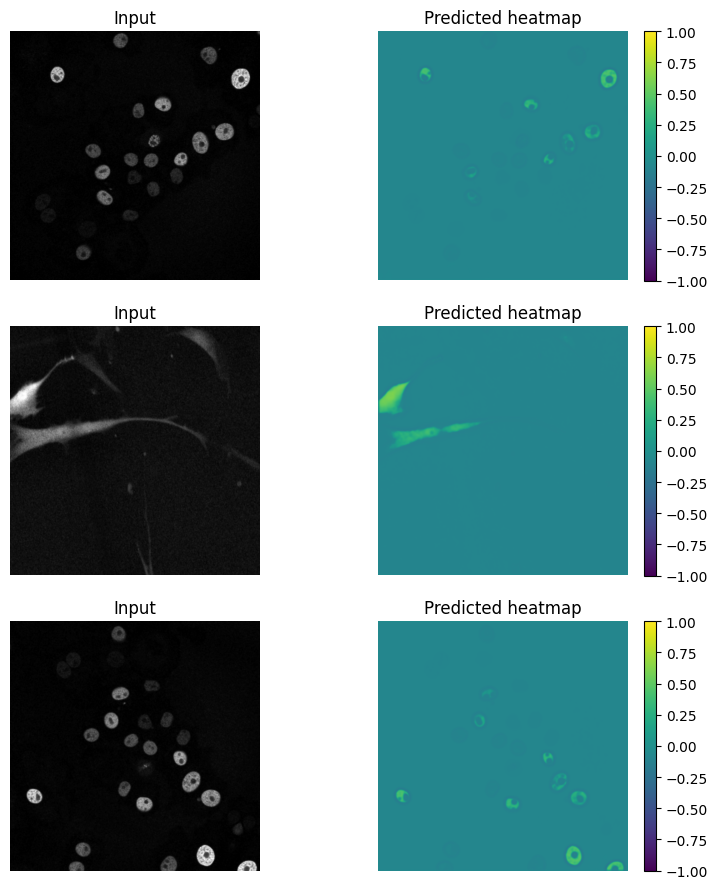

In [26]:
# Testing and visualization
import matplotlib.pyplot as plt
import torch


@torch.no_grad()
def show_predictions(model, dataloader, device, num_samples=3):
    """Plot 3 examples: input image vs predicted heatmap."""
    model.eval()

    examples = []  # list of (img_hw, pred_hw) on CPU
    for images, _targets in dataloader:
        # images: [B,1,H,W]
        images = images.to(device)
        preds = model(images)  # [B,1,H,W] in [-1,1]
        images_cpu = images.detach().cpu()
        preds_cpu = preds.detach().cpu()

        for i in range(images_cpu.shape[0]):
            img_hw = images_cpu[i, 0].numpy()
            pred_hw = preds_cpu[i, 0].numpy()
            examples.append((img_hw, pred_hw))
            if len(examples) >= num_samples:
                break
        if len(examples) >= num_samples:
            break

    if len(examples) == 0:
        raise RuntimeError("No samples found in dataloader.")

    fig, axes = plt.subplots(len(examples), 2, figsize=(8, 3 * len(examples)))
    if len(examples) == 1:
        axes = [axes]  # normalize to list of rows
    for row, (img_hw, pred_hw) in enumerate(examples):
        ax_in, ax_out = axes[row]
        ax_in.imshow(img_hw, cmap="gray")
        ax_in.set_title("Input")
        ax_in.axis("off")

        im = ax_out.imshow(pred_hw, cmap="viridis", vmin=-1.0, vmax=1.0)
        ax_out.set_title("Predicted heatmap")
        ax_out.axis("off")
        fig.colorbar(im, ax=ax_out, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


# Show 3 training examples (run after you've trained, or run anytime to see current outputs)
show_predictions(model, train_loader, DEVICE, num_samples=3)